# BÀI TẬP VỀ NHÀ

# Dự báo chuỗi thời gian bằng RNN

## Mô tả bài toán

Trong buổi học trên lớp, chúng ta đã làm quen với bài toán dự báo chuỗi thời gian bằng mô hình RNN trên dữ liệu sóng sin đơn giản.  
Để hiểu sâu hơn về cách hoạt động của mô hình và rèn luyện kỹ năng xử lý dữ liệu chuỗi, ở bài tập này em sẽ xây dựng một mô hình dự báo trên **dữ liệu đa biến**, phức tạp hơn so với ví dụ trên lớp.

Mục tiêu của bài là sử dụng các giá trị trong quá khứ của nhiều đặc trưng để dự đoán giá trị của biến mục tiêu ở thời điểm tiếp theo.

## Mục tiêu cần đạt

Sau khi hoàn thành bài tập, em cần:

- Biết cách tạo và xử lý dữ liệu chuỗi thời gian.
- Biết cách chuẩn hóa dữ liệu trước khi đưa vào mô hình.
- Biết cách tạo các chuỗi con phục vụ huấn luyện.
- Xây dựng được mô hình RNN bằng PyTorch.
- Thực hiện huấn luyện, đánh giá và trực quan hóa kết quả.

## Dữ liệu sử dụng

Khác với ví dụ trên lớp chỉ có một chuỗi sin, trong bài này dữ liệu gồm nhiều đặc trưng hơn:

- `feature_1`: chuỗi dạng sin
- `feature_2`: chuỗi dạng cos
- `feature_3`: chuỗi có xu hướng tăng nhẹ kèm nhiễu
- `target`: biến mục tiêu được tạo từ tổ hợp của các đặc trưng trên

   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


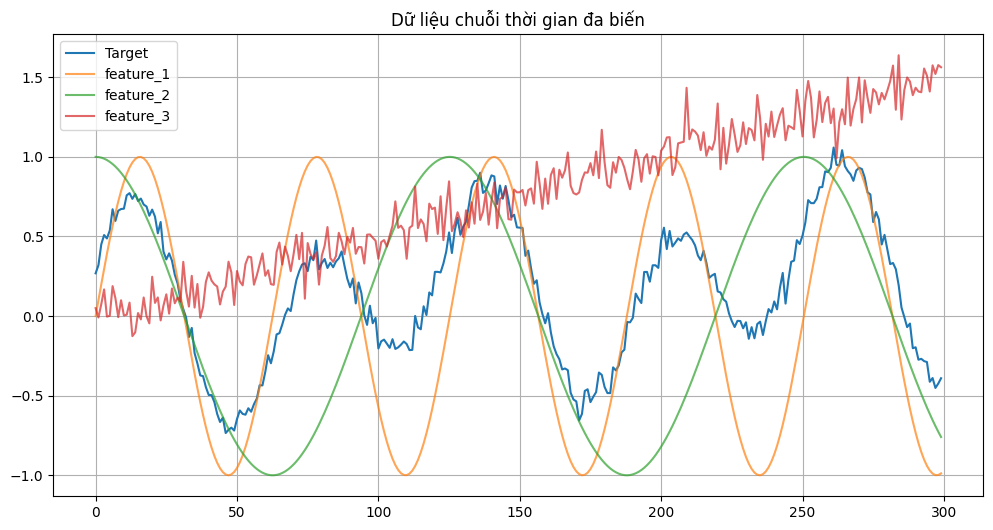

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)

feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)

target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target
})

print(df.head())

plt.figure(figsize=(12,6))
plt.plot(df['target'], label='Target')
plt.plot(df['feature_1'], label='feature_1', alpha=0.7)
plt.plot(df['feature_2'], label='feature_2', alpha=0.7)
plt.plot(df['feature_3'], label='feature_3', alpha=0.7)
plt.legend()
plt.title("Dữ liệu chuỗi thời gian đa biến")
plt.grid(True)
plt.show()

In [13]:
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

t = np.linspace(0, 100, 500)
data = np.column_stack([
    np.sin(t),
    np.cos(t),
    np.sin(2*t)
])

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

def create_sequences(data, seq_length=20):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])
    return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(data_scaled, seq_length)

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [14]:
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = RNNModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [15]:
epochs = 150
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()

    output = model(X_train)
    loss = criterion(output.squeeze(), y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output.squeeze(), y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

Epoch 10, Train Loss: 0.1459, Val Loss: 0.1264
Epoch 20, Train Loss: 0.1028, Val Loss: 0.0941
Epoch 30, Train Loss: 0.0761, Val Loss: 0.0686
Epoch 40, Train Loss: 0.0511, Val Loss: 0.0448
Epoch 50, Train Loss: 0.0113, Val Loss: 0.0085
Epoch 60, Train Loss: 0.0056, Val Loss: 0.0045
Epoch 70, Train Loss: 0.0033, Val Loss: 0.0029
Epoch 80, Train Loss: 0.0008, Val Loss: 0.0007
Epoch 90, Train Loss: 0.0004, Val Loss: 0.0003
Epoch 100, Train Loss: 0.0003, Val Loss: 0.0002
Epoch 110, Train Loss: 0.0002, Val Loss: 0.0002
Epoch 120, Train Loss: 0.0001, Val Loss: 0.0001
Epoch 130, Train Loss: 0.0001, Val Loss: 0.0001
Epoch 140, Train Loss: 0.0001, Val Loss: 0.0001
Epoch 150, Train Loss: 0.0001, Val Loss: 0.0001


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    predictions = model(X_test).squeeze().numpy()

y_test_np = y_test.numpy()

mse = mean_squared_error(y_test_np, predictions)
mae = mean_absolute_error(y_test_np, predictions)

print("MSE:", mse)
print("MAE:", mae)

MSE: 0.00011158465349581093
MAE: 0.009478982537984848


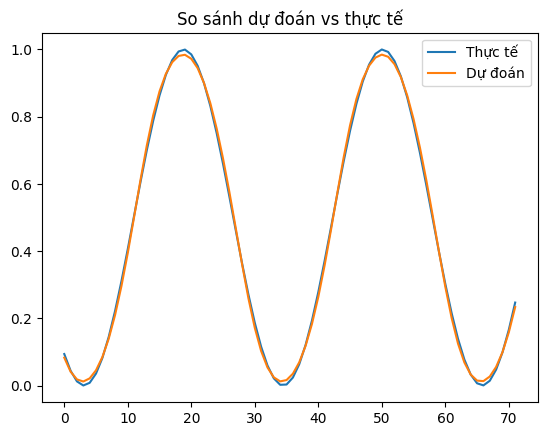

In [17]:
plt.figure()
plt.plot(y_test_np, label="Thực tế")
plt.plot(predictions, label="Dự đoán")
plt.legend()
plt.title("So sánh dự đoán vs thực tế")
plt.show()